# Extracting spectra from full detector image

**Author:** Tri L. Astraatmadja, tastraatmadja@stsci.edu
<br>
**Date:** August 25 2026

This note demonstrates some technique to extract 1d spectra from a <i>Roman</i> full detector image.

A scene containing stars and galaxies have been simulated using `Ilia` (a simulator and reconstruction code written by yours truly), with output in ASDF format. This is the data format we're going to expect from <i>Roman</i> data.

## Loading and displaying the images

The images are located in the directory `../prism_images`. The images are simulated F146 and prism observation using the WFI05 aperture, and is centered around the same coordinates. Like the grism counterpart, it has the same four roll angles. Let's see what the file looks like.

In [1]:
import os

data_dir = "../prism_images"

filenames = sorted(os.listdir(data_dir))

filenames

['spqr_data_challenge_0001_wfi05_f146_cal.asdf',
 'spqr_data_challenge_0001_wfi05_f146_cal.pkl',
 'spqr_data_challenge_0001_wfi05_prism_cal.asdf',
 'spqr_data_challenge_0002_wfi05_f146_cal.asdf',
 'spqr_data_challenge_0002_wfi05_f146_cal.pkl',
 'spqr_data_challenge_0002_wfi05_prism_cal.asdf',
 'spqr_data_challenge_0003_wfi05_f146_cal.asdf',
 'spqr_data_challenge_0003_wfi05_f146_cal.pkl',
 'spqr_data_challenge_0003_wfi05_prism_cal.asdf',
 'spqr_data_challenge_0004_wfi05_f146_cal.asdf',
 'spqr_data_challenge_0004_wfi05_f146_cal.pkl',
 'spqr_data_challenge_0004_wfi05_prism_cal.asdf']

There are four roll angles, and for each roll angle there are two filters. Let's plot the images

In [2]:
from astropy import coordinates, units as u

In [3]:
n_roll_angles = 4

filter_names = ['F146', 'PRISM']

detector_name = 'WFI05'

base_filename = 'spqr_data_challenge'

central_coords = coordinates.SkyCoord(150.1271594, 2.3351436, frame='icrs', unit='deg')

In [44]:
from matplotlib import gridspec, pyplot as plt, ticker
import numpy as np
import roman_datamodels as rdm ## We will use the roman_datamodels package to read ASDF files

In [5]:
## Some plotting settings
plt.rc('font', family='serif')
plt.rc('text', usetex=True) ## Comment this line if you don't have TeX installed
plt.rc('font', size=16)     ## Reduce this number if you don't like big text
plt.rc('xtick', direction='in', top=True, bottom=True)
plt.rc('ytick', direction='in', left=True, right=True)

0 0 WFI05 F146 0d00m00s
0 1 WFI05 F146 150d00m00s
0 2 WFI05 F146 182d00m00s
0 3 WFI05 F146 214d00m00s
1 0 WFI05 PRISM 0d00m00s
1 1 WFI05 PRISM 150d00m00s
1 2 WFI05 PRISM 182d00m00s
1 3 WFI05 PRISM 214d00m00s


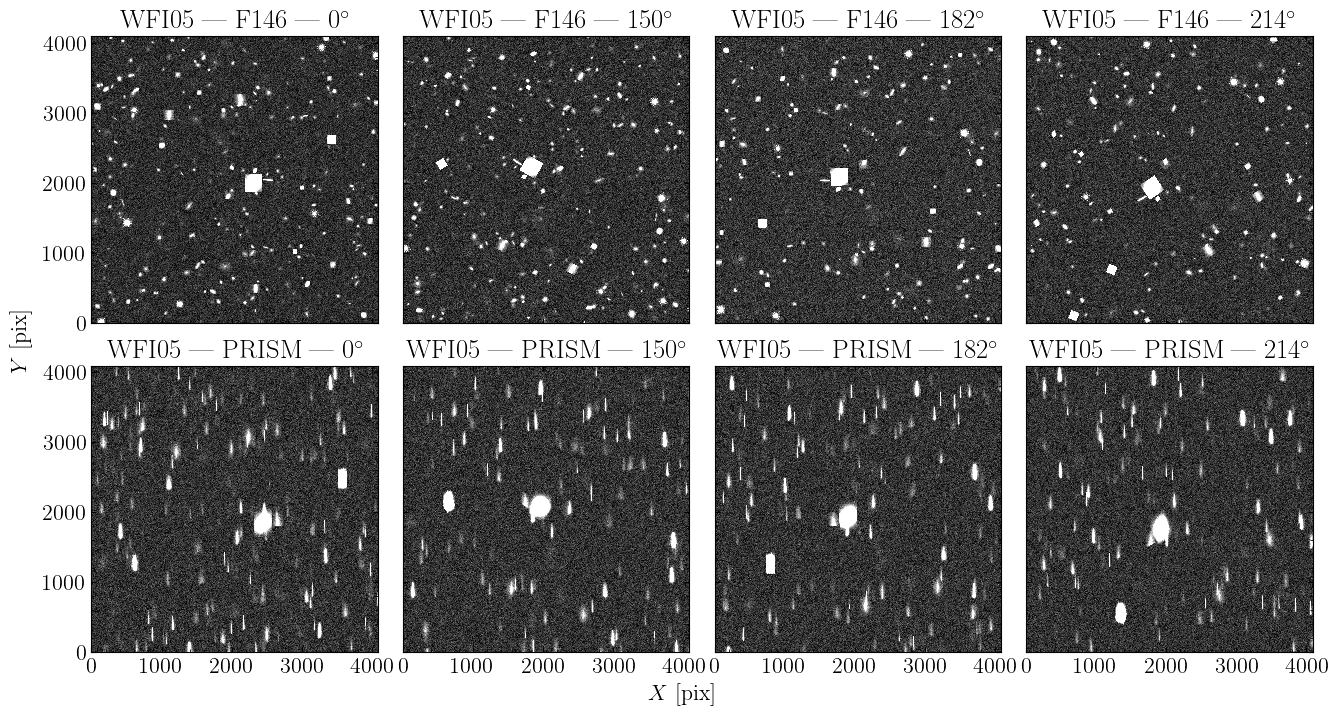

In [6]:
nCols = n_roll_angles ## Number of roll angles
nRows = len(filter_names) ## Number of filters

x_plot_size = 4
xSize = x_plot_size * nCols
ySize = nRows * x_plot_size

dX, dMX = 1000, 200
dY, dMY = dX, dMX

CI   = 97.0
P_LO = 0.5 * (100.0 - CI)
P_HI = 0.5 * (100.0 + CI)

fig, axes = plt.subplots(figsize=(xSize, ySize), nrows=nRows, ncols=nCols, sharex=True, sharey=True, squeeze=False)

plt.subplots_adjust(wspace=0.02, hspace=0.15)

for i, filter_name in enumerate(filter_names):
    for j in range(n_roll_angles):
        filename = '{}/{}_{:04d}_{}_{}_cal.asdf'.format('../prism_images',
                                                    base_filename,
                                                    j+1,
                                                    detector_name.lower(), 
                                                    filter_name.lower())

        with rdm.open(filename) as dm:
            roll_angle = coordinates.Angle(360.0 * u.deg - dm.meta.pointing.pa_aperture * u.deg).wrap_at(360.0 * u.deg)
            
            image = dm.data
            title = '{:s} --- {:s} --- {:0.0f}'.format(dm.meta.instrument['detector'],
                                                       dm.meta.instrument['optical_element'],
                                                       roll_angle.value)+r'$^\circ$'
        
            vmin, vmax = np.percentile(image, P_LO), np.percentile(image, P_HI)

            axes[i,j].imshow(image, aspect='equal', cmap='gray', origin='lower', vmin=vmin, vmax=vmax, interpolation='nearest')
            
            axes[i,j].set_title(title)

            print(i, j, dm.meta.instrument['detector'], dm.meta.instrument['optical_element'], roll_angle)

            axes[i,j].xaxis.set_major_locator(ticker.MultipleLocator(dX))
            axes[i,j].xaxis.set_minor_locator(ticker.MultipleLocator(dMX))

            axes[i,j].yaxis.set_major_locator(ticker.MultipleLocator(dY))
            axes[i,j].yaxis.set_minor_locator(ticker.MultipleLocator(dMY))

fig.text(0.5, 0.05, r'$X$ [pix]', ha='center');
fig.text(0.08, 0.5, r'$Y$ [pix]', va='center', rotation='vertical');

Each image also comes with a pickle file containing a table of sources that are simulated. Let's plot one of the files with the sources plotted.

In [7]:
import pandas as pd

In [8]:
## Plotting source list
df_sources = pd.read_pickle("../prism_images/spqr_data_challenge_0001_wfi05_f146_cal.pkl")

df_sources

,source_id,ra,dec,pmra,pmdec,radial_velocity,mag_g,mag_bp,mag_rp,mag_rvs,...,feh,alphafe,mbol,type,n,half_light_radius,pa,ba,F087,F146
233,2.154198e+18,150.065143,2.388045,-8.397645,-5.679357,3.122432,14.740502,15.230218,14.071490,13.841483,...,-0.034167,0.051189,6.46,PSF,NaN,NaN,NaN,NaN,NaN,NaN
237,2.154198e+18,150.066232,2.325179,-6.079847,1.833236,42.083637,19.345242,20.033451,18.509583,18.186235,...,0.117223,0.101771,7.58,PSF,NaN,NaN,NaN,NaN,NaN,NaN
253,2.154198e+18,150.071405,2.304669,-1.269171,-2.682573,44.513214,18.495920,19.171848,17.670479,17.349867,...,-0.133097,0.149273,7.44,PSF,NaN,NaN,NaN,NaN,NaN,NaN
255,2.154198e+18,150.071413,2.304689,-1.269172,-2.682576,45.319225,22.750809,24.284714,21.485968,20.952131,...,-0.133097,0.149273,11.02,PSF,NaN,NaN,NaN,NaN,NaN,NaN
256,2.154198e+18,150.071791,2.380178,-0.142856,-5.433418,49.233627,18.319441,18.993002,17.495773,17.176292,...,-0.103521,0.168065,7.30,PSF,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49162,NaN,150.188451,2.359943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,SER,3.094534,0.634990,288.518555,0.765204,5.048657e-09,1.023818e-08
49172,NaN,150.188496,2.372037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,SER,2.535988,0.716336,55.194172,0.792536,7.523887e-09,1.515670e-08
49180,NaN,150.188521,2.311007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,SER,2.706726,0.563025,220.771072,0.977818,3.733387e-09,5.178472e-09
49271,NaN,150.188957,2.350164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,SER,1.454262,0.875343,254.016098,0.376284,6.730368e-09,9.373272e-09


The coordinates, however, are still in (RA, DEC) celestial coordinates. To get the $(x,y)$ coordinates in the science frame, we can use `pysiaf`

In [9]:
import pysiaf

rsiaf = pysiaf.Siaf('roman')

aperture = rsiaf['{}_FULL'.format(detector_name)]

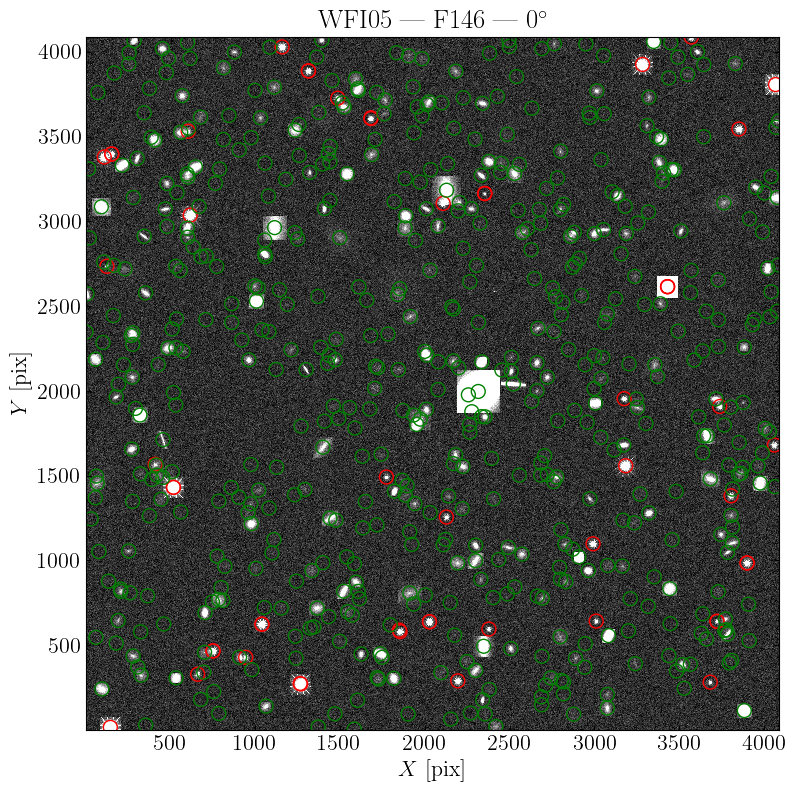

In [10]:
x_size = 9
y_size = x_size

fig, ax = plt.subplots(figsize=(x_size, x_size))

## In the catalogue, there are two types of object, Stars (PSF) or Galaxies (SER).
## We'll plot them with different colors
source_types  = ['PSF', 'SER']
source_colors = ['r', 'g']

filename = filenames[0]

with rdm.open(data_dir+'/'+filename) as dm:
    roll_angle = coordinates.Angle(360.0 * u.deg - dm.meta.pointing.pa_aperture * u.deg).wrap_at(360.0 * u.deg)
                        
    title = '{:s} --- {:s} --- {:0.0f}'.format(dm.meta.instrument['detector'],
                                               dm.meta.instrument['optical_element'],
                                               roll_angle.value)+r'$^\circ$'

    image = dm.data

    vmin, vmax = np.percentile(image, P_LO), np.percentile(image, P_HI)

    ax.imshow(image, aspect='equal', cmap='gray', origin='lower', vmin=vmin, vmax=vmax, 
                     interpolation='nearest', extent=(0.5, image.shape[1]+0.5, 0.5, image.shape[0]+0.5))
    
    ax.set_title(title)

    ax.set_xlabel(r'$X$ [pix]')
    ax.set_ylabel(r'$Y$ [pix]')

    ax.set_xlim(0.5, image.shape[1]+0.5)
    ax.set_ylim(0.5, image.shape[0]+0.5)

    ## We use pysiaf to reconstruct the attitude matrix when the observation was taken.
    ## First we need some information.
    
    ## We need the V2/V3 coordinates at the center of the detector
    v2_cen, v3_cen = aperture.idl_to_tel(0, 0) 

    ## We need the position angle of the y-axis relative to the V3 axis
    pa_y_v3 = coordinates.Angle(aperture.V3IdlYAngle, unit= u.deg)

    ## Then we calculate the position angle of the V3 axis relative to the celestial axis
    pa_v3   = (360.0 * u.deg - pa_y_v3 - roll_angle).wrap_at(360.0 * u.deg)

    ## Finally we calculate the attitude matrix, then put it in the aperture
    att = pysiaf.rotations.attitude(v2_cen, v3_cen, central_coords.ra, central_coords.dec, pa_v3)
    aperture.set_attitude_matrix(att)

    ## x, y science coordinates can then be calculated from the celestial coordinates
    for source_type, source_color in zip(source_types, source_colors):
        selection = df_sources['type'] == source_type

        x_src, y_src = aperture.sky_to_sci(df_sources.loc[selection, 'ra'], df_sources.loc[selection, 'dec'])

        ax.scatter(x_src, y_src, s=100, facecolors='none', edgecolors=source_color)

In [11]:
## Let's concentrate on our object of interest. We have injected an (unusually bright) Lyman-Alpha emitter in the vicinity. The coordinate is known to us. Let's plot the image again but limited to where source is

In [12]:
## SOURCE_RA, SOURCE_DEC = 150.11580883588812, 2.351349033211921

## x_src, y_src = aperture.sky_to_sci(SOURCE_RA, SOURCE_DEC)

## x_src, y_src

Let's have a look at a star. Let's say we know the celestial coordinate of the star. We plot the image again but limited to a box 500 pixel wide centered to the star.

In [13]:
SOURCE_RA, SOURCE_DEC = 150.1488491471225, 2.389555618835918

x_src, y_src = aperture.sky_to_sci(SOURCE_RA, SOURCE_DEC)

x_src, y_src

(1312.5109590105044, 3887.8581969648276)

0 spqr_data_challenge_0001_wfi05_f146_cal.asdf
1 spqr_data_challenge_0001_wfi05_prism_cal.asdf


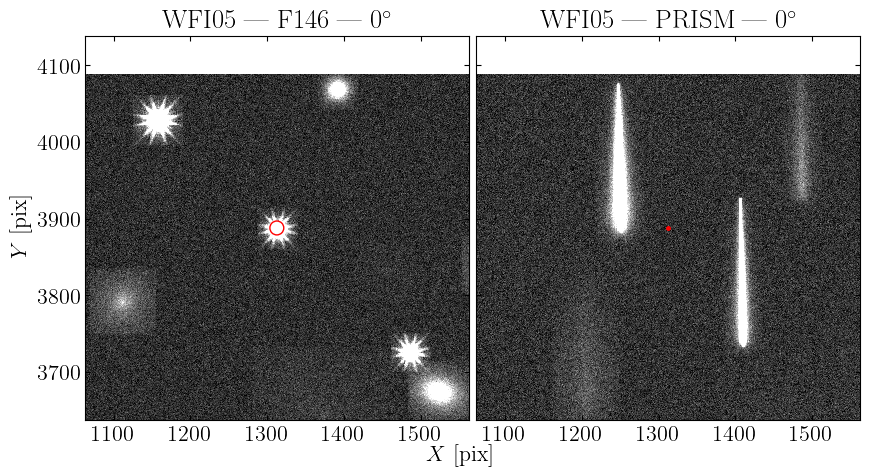

In [14]:
nCols = 2
nRows = 1

x_plot_size = 5

xSize = x_plot_size * nCols
ySize = nRows * x_plot_size

fig, axes = plt.subplots(figsize=(xSize, ySize), nrows=nRows, ncols=nCols, sharex=True, sharey=True)

plt.subplots_adjust(wspace=0.02)

file_list = [filenames[0], filenames[2]]

dx_lo, dx_hi = 250, 250
dy_lo, dy_hi = 250, 250

for i, filename in enumerate(file_list):
    print(i, filename)
    with rdm.open(data_dir+'/'+filename) as dm:
        roll_angle = coordinates.Angle(360.0 * u.deg - dm.meta.pointing.pa_aperture * u.deg).wrap_at(360.0 * u.deg)
                        
        title = '{:s} --- {:s} --- {:0.0f}'.format(dm.meta.instrument['detector'],
                                                   dm.meta.instrument['optical_element'],
                                                   roll_angle.value)+r'$^\circ$'
    
        image = dm.data
    
        vmin, vmax = np.percentile(image, P_LO), np.percentile(image, P_HI)
    
        axes[i].imshow(image, aspect='equal', cmap='gray', origin='lower', vmin=vmin, vmax=vmax, 
                         interpolation='nearest', extent=(0.5, image.shape[1]+0.5, 0.5, image.shape[0]+0.5))
        
        axes[i].set_title(title)

        if ('RISM' in dm.meta.instrument['optical_element']):
            axes[i].plot(x_src, y_src, '.', markersize=5, color='r')
        else:
            axes[i].scatter(x_src, y_src, s=100, facecolors='none', edgecolors='r')

        axes[i].set_xlim(x_src - dx_lo, x_src + dx_hi)
        axes[i].set_ylim(y_src - dy_lo, y_src + dy_hi)

fig.text(0.5, 0.03, r'$X$ [pix]', ha='center');
fig.text(0.05, 0.5, r'$Y$ [pix]', va='center', rotation='vertical');

We mark the location of the star by a red open circle in the undispersed image, and with a dot on the same location in the dispersed image. As we can see, the location of the corresponding spectrum is shifted by about 100 pixel to the right.

If we know the model for the trace, which calculate the trace coordinate $(x_{\rm tr},y_{\rm tr})$ for a given point $(x_0, y_0)$ in the undispersed image and with wavelength $\lambda$, then it is straightforward to extract a 1d spectrum of a source.

But suppose we don't have a model (or we want to build such model), so how can we nevertheless extract 1d spectra?

What we can do is we make an approximate cutout of the spectrum of interest. We then scan along the dispersion axis (in this case, the vertical axis), and for each row index $y_{\rm tr}$ in the cutout we perform a centroiding routine along the cross-dispersion axis (here the horizontal axis) to find the centroid $x_{\rm tr}$ of the spectrum at the given row index.

Let's try this. First we define a scanning window based on the image coordinate $(x_0, y_0)$ of the source in the undispersed image:

In [112]:
## Calculate the scanning window in image coordinates

## Here the image coordinates (x_src, y_src) are 1-indexed, i.e. starts from one. We transform
## them into pixel index, which are 0-indexed (starts from zero).
x0 = x_src - 1 
y0 = y_src - 1

## This is pixel index so it must be integers.
x0_pix = int(x0)
y0_pix = int(y0)

## We define the offset from the source
dx_lo = 5
dx_hi = 145

dy_lo = 180
dy_hi = 60

naxis2, naxis1 = image.shape

## This is the coordinates for the edges of the scanning window
x_min = max(0, x0_pix - dx_lo)
x_max = min(naxis1 - 1, x0_pix + dx_hi)
y_min = max(0, y0_pix - dy_lo)
y_max = min(naxis2 - 1, y0_pix + dy_hi)

size_x = x_max - x_min + 1
size_y = y_max - y_min + 1

print(x_min, x_max, y_min, y_max)
print(size_x, size_y)

## Now we extract the 2d cutout from the full image
filename = file_list[1]

with rdm.open(data_dir+'/'+filename) as dm:
    prism_cutout = dm.data[y_min:y_max+1, x_min:x_max+1]
    prism_var    = dm.err[y_min:y_max+1, x_min:x_max+1] ** 2

## Coordinates are 0-indexed
x_coords = np.arange(x_min, x_max+1)
y_coords = np.arange(y_min, y_max+1)

1306 1456 3706 3946
151 241


Let's plot the cutout and inspect the flux distribution along the cross-dispersion axis direction.

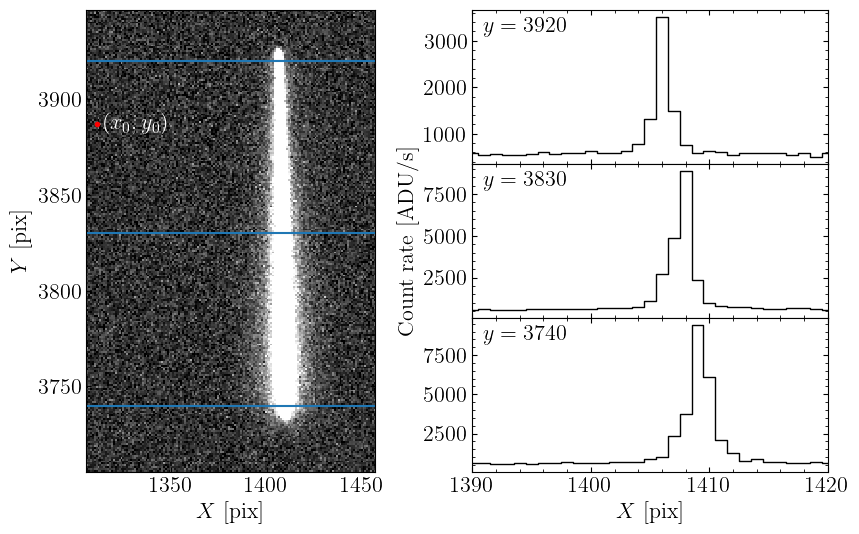

In [163]:
x_size = 10
y_size = 6

fig = plt.figure(figsize=(x_size, y_size))

gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1], wspace=0.18, hspace=0)

ax = fig.add_subplot(gs[:,0])

CI   = 90
P_LO = 0.5 * (100.0 - CI)
P_HI = 0.5 * (100.0 + CI)

vmin, vmax = np.percentile(prism_cutout, P_LO), np.percentile(prism_cutout, P_HI)
    
ax.imshow(prism_cutout, aspect='equal', cmap='gray', origin='lower', vmin=vmin, vmax=vmax,
          interpolation='nearest', extent=(x_min-0.5, x_max+0.5, y_min-0.5, y_max+0.5))

ax.plot(x0, y0, 'r.')

ax.set_xlabel(r'$X$ [pix]')
ax.set_ylabel(r'$Y$ [pix]')

ax.annotate(r'$(x_0, y_0)$', (x0, y0), xytext=(5, 0), xycoords='data', 
            textcoords='offset points', color='w', va='center', ha='left')

y_slices = np.array([3920, 3830, 3740], dtype=int)

xMin = 1390
xMax = 1420

dX, dMX = 10, 2

for i, y_slice in enumerate(y_slices):
    ax.axhline(y_slice)

    ax1 = fig.add_subplot(gs[i, 1])

    ax1.text(0.03, 0.95, r'$y = '+'{:d}'.format(y_slice)+r'$', 
             ha='left', va='top', transform=ax1.transAxes)

    lsf     = prism_cutout[y_slice - y_min]
    xCoords = x_coords

    ax1.step(xCoords, lsf, where='mid', linewidth=1, color='k')

    ax1.set_xlim(xMin, xMax)

    if (i < (y_slices.size - 1)):
        ax1.set_xticklabels('')
    else:
        ax1.set_xlabel(r'$X$ [pix]')

    if (i == int(y_slices.size // 2)):
        ax1.set_ylabel(r'Count rate [ADU/s]')

    ax1.xaxis.set_major_locator(ticker.MultipleLocator(dX))
    ax1.xaxis.set_minor_locator(ticker.MultipleLocator(dMX))

    ax1.yaxis.set_major_locator(ticker.AutoLocator())
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())